<a href="https://colab.research.google.com/github/mgopal64/pinn-gelman-dioxane-modeling/blob/main/GelmanPINNLOWOValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
PKL_PATH = '/content/drive/MyDrive/gelman-pinn/merged_df.pkl'

# ==========================================
# 1. CONFIGURATION
# ==========================================
SOURCE_COORD = np.array([13278097.0, 279314.0])
TARGET_COORD = np.array([13286705.0, 298215.0])
X_MAX_DIST = 18178.0
T_MAX_YEARS = 70.0
C_LOG_MAX = np.log10(212000 + 1)
T_START_DATE = pd.Timestamp('1986-01-01')

# Depth Band Selection
MIN_DEPTH = 130
MAX_DEPTH = 170

# Training Config
ADAM_EPOCHS = 3000
LEARNING_RATE = 1e-3
PHYSICS_WEIGHT = 5.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# ==========================================
# 2. DATA LOADING WITH SCREEN DEPTH
# ==========================================
def get_screen_midpoint(interval, fallback_depth):
    """Extract midpoint from Screen_Interval string (e.g., '140-155')."""
    if pd.isna(interval) or interval == 'unknown':
        return np.nan  # Return NaN instead of fallback to avoid TotalDepth contamination
    try:
        top, bot = map(float, str(interval).split('-'))
        return (top + bot) / 2
    except:
        return np.nan

def get_transect_coords(df):
    line_vec = TARGET_COORD - SOURCE_COORD
    line_len = np.linalg.norm(line_vec)
    line_unit = line_vec / line_len

    points = df[['Easting', 'Northing']].values.astype(float)
    point_vec = points - SOURCE_COORD

    along = np.dot(point_vec, line_unit)
    proj = SOURCE_COORD + np.outer(along, line_unit)
    perp = np.linalg.norm(points - proj, axis=1)
    return along, perp

def load_data():
    print(f"Loading {PKL_PATH}...")
    df = pd.read_pickle(PKL_PATH)

    # Clean Coordinates
    df['Easting'] = pd.to_numeric(df['Easting'], errors='coerce')
    df['Northing'] = pd.to_numeric(df['Northing'], errors='coerce')
    df.dropna(subset=['Easting', 'Northing'], inplace=True)

    # Calculate Transect Position
    df['along_dist_ft'], df['perp_dist_ft'] = get_transect_coords(df)

    # =========================================
    # KEY FIX: Use Screen_Midpoint, NOT TotalDepth
    # =========================================
    df['Screen_Midpoint'] = df.apply(
        lambda row: get_screen_midpoint(row['Screen_Interval'], row['TotalDepth']),
        axis=1
    )

    # Drop rows where screen interval couldn't be parsed
    n_before = len(df)
    df = df.dropna(subset=['Screen_Midpoint'])
    n_after = len(df)
    print(f"Screen Interval Filter: {n_before} → {n_after} samples ({n_before - n_after} dropped)")

    # Filter for Unit E (130-170 ft) using SCREEN MIDPOINT
    df = df[
        (df['perp_dist_ft'].abs() <= 1000) &
        (df['along_dist_ft'] >= -100) &
        (df['Screen_Midpoint'].between(MIN_DEPTH, MAX_DEPTH)) &  # ✅ FIXED
        (df['Value'].notna())
    ].copy()

    # Filter Noise/Non-Detects
    df = df[df['Value_tx'] != 'Not Detected'].copy()
    df = df[df['Value'] > 0.5].copy()

    # Normalization (matching training pipeline exactly)
    df['SampleDate'] = pd.to_datetime(df['SampleDate'])
    df['t_years'] = (df['SampleDate'] - T_START_DATE).dt.days / 365.25
    df['C_norm'] = np.log10(df['Value'] + 1) / C_LOG_MAX
    df['x_norm'] = df['along_dist_ft'] / X_MAX_DIST
    df['t_norm'] = df['t_years'] / T_MAX_YEARS
    df['z_norm'] = (df['Screen_Midpoint'] - MIN_DEPTH) / (MAX_DEPTH - MIN_DEPTH)  # Added z_norm

    return df

# Load data
full_df = load_data()
well_list = full_df['Bore'].unique()
print(f"Dataset Ready: {len(full_df)} samples from {len(well_list)} unique wells.")
print(f"Screen Depth Range: {full_df['Screen_Midpoint'].min():.0f} - {full_df['Screen_Midpoint'].max():.0f} ft")

# ==========================================
# 3. MODEL ARCHITECTURE (3-Input Version)
# ==========================================
class DioxanePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64), nn.Tanh(),  # 3 inputs: x, z, t
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1), nn.Sigmoid()
        )
        self.v_raw = nn.Parameter(torch.tensor([0.0]))
        self.D_raw = nn.Parameter(torch.tensor([0.0]))

    def forward(self, x_combined):
        """Expects [x, z, t] concatenated tensor."""
        return self.net(x_combined)

    def get_physics_params(self):
        # Unit E bounds: 170-350 ft/yr velocity, 2000-8000 ft²/yr dispersion
        v = 0.46 + (0.96 - 0.46) * torch.sigmoid(self.v_raw)
        D = 5.47 + (21.90 - 5.47) * torch.sigmoid(self.D_raw)
        return v, D

def physics_loss(model, x_c):
    """3D ADE physics loss with vertical dispersion."""
    x_c.requires_grad_(True)

    v_day, D_day = model.get_physics_params()
    v, D = v_day * 365.25, D_day * 365.25

    C = model(x_c)

    grads = torch.autograd.grad(C, x_c, torch.ones_like(C), create_graph=True)[0]
    C_x = grads[:, 0:1] / X_MAX_DIST
    C_z = grads[:, 1:2] / (MAX_DEPTH - MIN_DEPTH)
    C_t = grads[:, 2:3] / T_MAX_YEARS

    C_xx = torch.autograd.grad(C_x, x_c, torch.ones_like(C_x), create_graph=True)[0][:, 0:1] / X_MAX_DIST
    C_zz = torch.autograd.grad(C_z, x_c, torch.ones_like(C_z), create_graph=True)[0][:, 1:2] / (MAX_DEPTH - MIN_DEPTH)

    # ADE with vertical component
    residual = C_t + v*C_x - D*C_xx - (D * 0.1)*C_zz
    return torch.mean(residual**2)

# Global Collocation Points (3D)
x_col = torch.rand(10000, 1, device=device)
z_col = torch.rand(10000, 1, device=device)
t_col = torch.rand(10000, 1, device=device)
col_input = torch.cat([x_col, z_col, t_col], dim=1).requires_grad_(True)

# ==========================================
# 4. LEAVE-ONE-WELL-OUT (LOWO) LOOP
# ==========================================
results = []
print(f"\n--- Starting LOWO Validation on {len(well_list)} Wells ---")

for i, target_well in enumerate(well_list):
    print(f"Processing {i+1}/{len(well_list)}: Hiding {target_well}...", end=" ")

    # A. SPLIT DATA
    train_subset = full_df[full_df['Bore'] != target_well]
    test_subset = full_df[full_df['Bore'] == target_well]

    if len(test_subset) < 3:
        print("Skipped (too few points)")
        continue

    # Prepare 3-Input Tensors
    X_tr = torch.tensor(train_subset['x_norm'].values, dtype=torch.float32).view(-1,1).to(device)
    Z_tr = torch.tensor(train_subset['z_norm'].values, dtype=torch.float32).view(-1,1).to(device)
    T_tr = torch.tensor(train_subset['t_norm'].values, dtype=torch.float32).view(-1,1).to(device)
    C_tr = torch.tensor(train_subset['C_norm'].values, dtype=torch.float32).view(-1,1).to(device)
    train_input = torch.cat([X_tr, Z_tr, T_tr], dim=1)

    X_te = torch.tensor(test_subset['x_norm'].values, dtype=torch.float32).view(-1,1).to(device)
    Z_te = torch.tensor(test_subset['z_norm'].values, dtype=torch.float32).view(-1,1).to(device)
    T_te = torch.tensor(test_subset['t_norm'].values, dtype=torch.float32).view(-1,1).to(device)
    test_input = torch.cat([X_te, Z_te, T_te], dim=1)
    C_true_norm = test_subset['C_norm'].values

    # B. INITIALIZE FRESH MODEL
    model = DioxanePINN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # C. TRAINING LOOP
    model.train()
    for epoch in range(ADAM_EPOCHS):
        optimizer.zero_grad()

        loss_d = torch.nn.functional.mse_loss(model(train_input), C_tr)
        loss_p = physics_loss(model, col_input)

        loss = loss_d + (PHYSICS_WEIGHT * loss_p)
        loss.backward()
        optimizer.step()

    # D. PREDICT HIDDEN WELL
    model.eval()
    with torch.no_grad():
        C_pred_norm = model(test_input).cpu().numpy().flatten()

    # E. CALCULATE METRICS
    C_true_ppb = 10**(C_true_norm * C_LOG_MAX) - 1
    C_pred_ppb = 10**(C_pred_norm * C_LOG_MAX) - 1

    C_pred_ppb = np.maximum(C_pred_ppb, 0.01)
    C_true_ppb = np.maximum(C_true_ppb, 0.01)

    rmse_ppb = np.sqrt(mean_squared_error(C_true_ppb, C_pred_ppb))
    log_rmse = np.sqrt(mean_squared_error(np.log10(C_true_ppb), np.log10(C_pred_ppb)))

    mean_val = np.mean(C_true_ppb)
    nrmse_pct = (rmse_ppb / mean_val) * 100 if mean_val > 0 else 0.0

    well_dist = test_subset['along_dist_ft'].iloc[0]
    well_depth = test_subset['Screen_Midpoint'].iloc[0]  # Now tracking screen depth

    results.append({
        'Well': target_well,
        'Dist_ft': well_dist,
        'Screen_ft': well_depth,  # NEW: Track actual screen depth
        'Samples': len(test_subset),
        'Mean_Obs_ppb': mean_val,
        'RMSE_ppb': rmse_ppb,
        'Error_%': nrmse_pct,
        'Log_RMSE': log_rmse
    })

    print(f"Screen: {well_depth:.0f}ft | Log-RMSE: {log_rmse:.3f} | Error: {nrmse_pct:.1f}%")

# ==========================================
# 5. RESULTS SUMMARY
# ==========================================
res_df = pd.DataFrame(results).sort_values('Dist_ft')
print("\n=== DEFENSIBLE LOWO RESULTS (Screen Depth Filtered) ===")
print(res_df[['Well', 'Screen_ft', 'Mean_Obs_ppb', 'RMSE_ppb', 'Error_%', 'Log_RMSE']].to_string(index=False, float_format="%.2f"))

# Summary Statistics
print(f"\n=== AGGREGATE METRICS ===")
print(f"Median Log-RMSE: {res_df['Log_RMSE'].median():.3f}")
print(f"Mean Log-RMSE:   {res_df['Log_RMSE'].mean():.3f}")
print(f"Wells within 0.5 Log-RMSE: {(res_df['Log_RMSE'] < 0.5).sum()}/{len(res_df)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on: cuda
Loading /content/drive/MyDrive/gelman-pinn/merged_df.pkl...
Screen Interval Filter: 28944 → 26682 samples (2262 dropped)
Dataset Ready: 1134 samples from 15 unique wells.
Screen Depth Range: 131 - 169 ft

--- Starting LOWO Validation on 15 Wells ---
Processing 1/15: Hiding MW-101... Screen: 158ft | Log-RMSE: 1.099 | Error: 122.1%
Processing 2/15: Hiding MW-110... Screen: 132ft | Log-RMSE: 0.592 | Error: 67.6%
Processing 3/15: Hiding MW-85... Screen: 160ft | Log-RMSE: 1.059 | Error: 96.8%
Processing 4/15: Hiding MW-88... Screen: 148ft | Log-RMSE: 0.964 | Error: 120.3%
Processing 5/15: Hiding MW-92... Screen: 148ft | Log-RMSE: 0.238 | Error: 48.0%
Processing 6/15: Hiding MW-BE-1d... Screen: 144ft | Log-RMSE: 0.759 | Error: 121.3%
Processing 7/15: Hiding 545 Allison... Screen: 145ft | Log-RMSE: 0.668 | Error: 265.1%
Processing 8/15: Hiding 580 A

In [6]:
# Check spatial distribution of problem wells
problem_wells = ['MW-101', 'MW-85', 'MW-88']
good_wells = ['MW-92', 'MW-110']

for well in problem_wells + good_wells:
    subset = full_df[full_df['Bore'] == well]
    print(f"{well}: x={subset['along_dist_ft'].iloc[0]:.0f}ft, "
          f"samples={len(subset)}, "
          f"years={subset['t_years'].min():.1f}-{subset['t_years'].max():.1f}")

MW-101: x=8868ft, samples=86, years=20.3-38.7
MW-85: x=7450ft, samples=138, years=17.2-39.0
MW-88: x=8027ft, samples=125, years=17.6-38.6
MW-92: x=9530ft, samples=89, years=18.7-38.8
MW-110: x=9475ft, samples=76, years=21.1-38.8


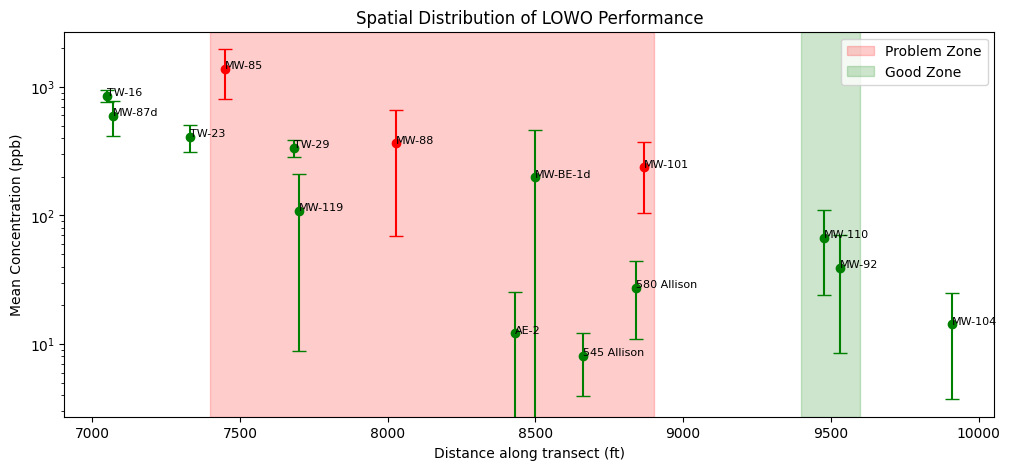

In [7]:
# Plot concentration vs distance for all wells
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

for well in full_df['Bore'].unique():
    subset = full_df[full_df['Bore'] == well]
    x = subset['along_dist_ft'].iloc[0]
    c_mean = subset['Value'].mean()
    c_std = subset['Value'].std()

    color = 'red' if well in ['MW-101', 'MW-85', 'MW-88'] else 'green'
    ax.errorbar(x, c_mean, yerr=c_std, fmt='o', color=color, capsize=5)
    ax.annotate(well, (x, c_mean), fontsize=8)

ax.axvspan(7400, 8900, alpha=0.2, color='red', label='Problem Zone')
ax.axvspan(9400, 9600, alpha=0.2, color='green', label='Good Zone')
ax.set_xlabel('Distance along transect (ft)')
ax.set_ylabel('Mean Concentration (ppb)')
ax.set_yscale('log')
ax.legend()
ax.set_title('Spatial Distribution of LOWO Performance')
plt.show()

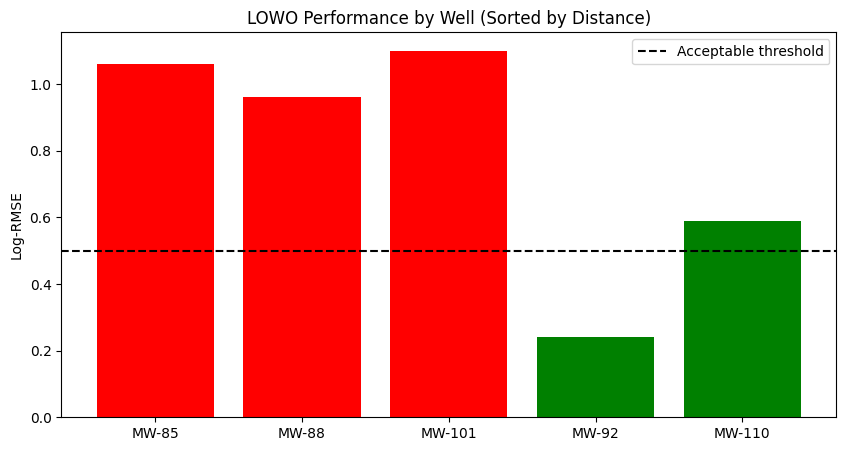

In [8]:
import matplotlib.pyplot as plt

wells = ['MW-85', 'MW-88', 'MW-101', 'MW-92', 'MW-110']
distances = [7450, 8027, 8868, 9530, 9475]
log_rmse = [1.06, 0.96, 1.10, 0.24, 0.59]

plt.figure(figsize=(10, 5))
colors = ['red' if lr > 0.8 else 'green' for lr in log_rmse]
plt.bar(wells, log_rmse, color=colors)
plt.axhline(0.5, color='black', linestyle='--', label='Acceptable threshold')
plt.ylabel('Log-RMSE')
plt.title('LOWO Performance by Well (Sorted by Distance)')
plt.legend()
plt.show()

METRICS THAT HIDE BIAS (Don't trust these alone)
Global R²:           0.869
Global RMSE:         177.57 ppb

METRICS THAT REVEAL BIAS (Trust these)
Log-space R²:        0.882  ← Treats 10ppb and 1000ppb equally
Log-RMSE:            0.275  ← <0.3 = within factor of 2
Mean Bias Error:     -41.15 ppb (-10.8%)  ← Positive = over-predicting
Log Bias:            -0.025  ← Positive = systematic over-prediction
Median APE:          18.9%  ← Robust to extreme values
SMAPE:               33.3%  ← Symmetric, bounded
Nash-Sutcliffe:      0.869  ← >0.5 = acceptable in hydrology

SPATIAL BIAS BY DISTANCE (Critical for PINN)
             along_dist_ft  C_true_ppb  C_pred_ppb  log_residual  \
Bore                                                               
TW-16              7049.03      851.67      672.72         -0.11   
MW-87d             7069.71      596.38      680.56          0.07   
TW-23              7331.93      410.74      381.28         -0.02   
MW-85              7449.70     1381.07    

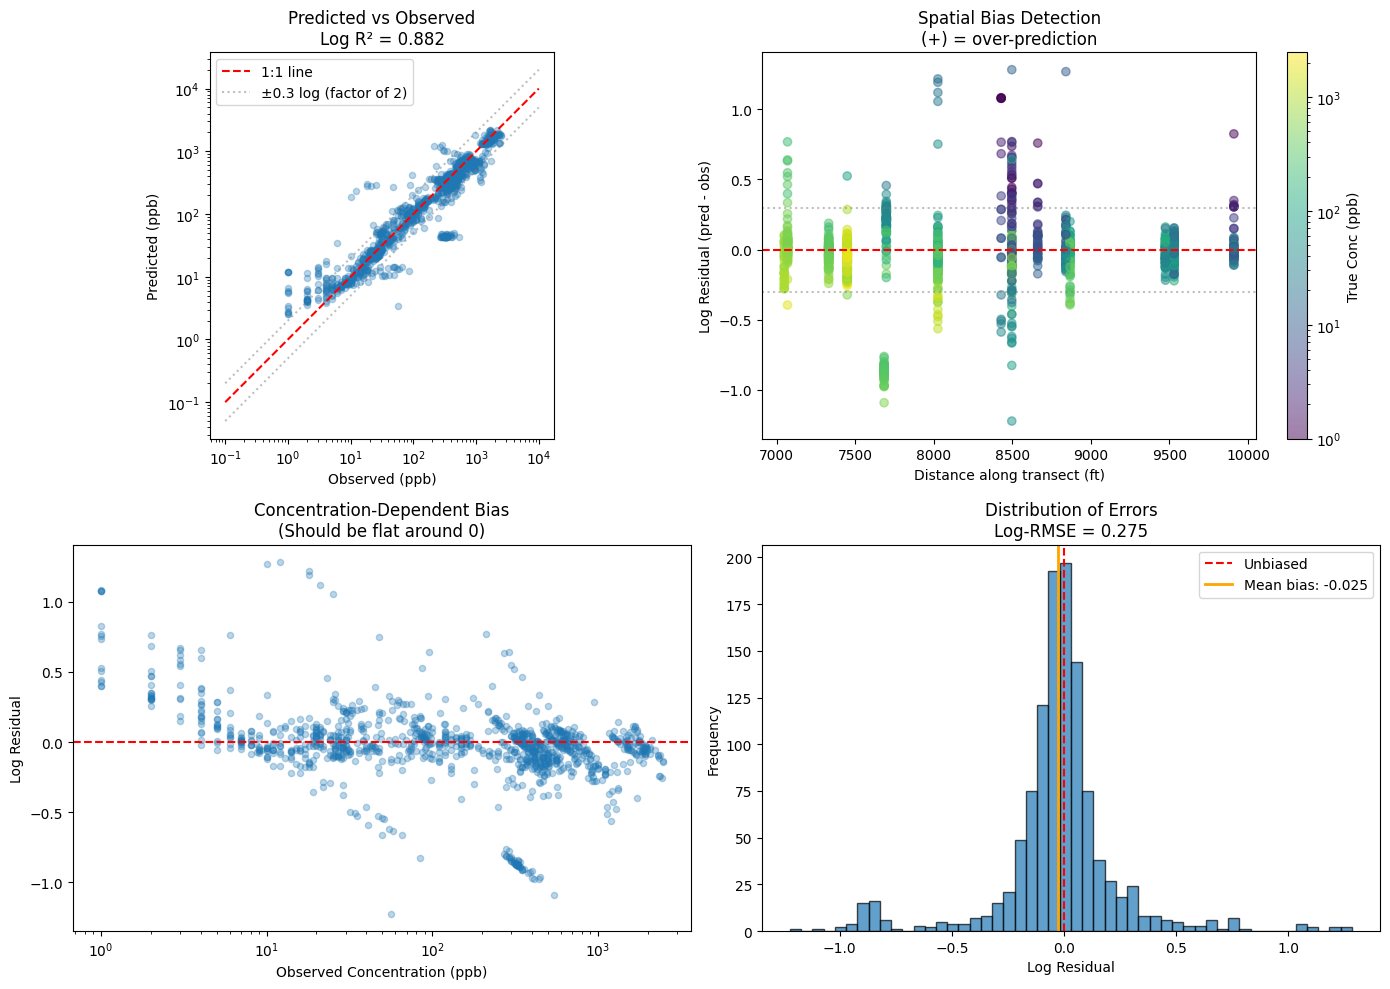


SUMMARY: METRICS FOR YOUR DEFENSE
        Metric  Value                    Interpretation
     Global R²  0.869       High but hides spatial bias
  Log-space R²  0.882 More honest across concentrations
      Log-RMSE  0.275                            ✓ Good
Nash-Sutcliffe  0.869                            ✓ Good
 Mean Log Bias -0.025                        ✓ Balanced


In [9]:
# ==========================================
# COMPREHENSIVE PINN VALIDATION METRICS
# ==========================================
# Calculates R² and bias-revealing metrics that R² hides

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import torch

# Assuming model, full_df, device, C_LOG_MAX are already defined

# ==========================================
# 1. GENERATE PREDICTIONS FOR ALL DATA
# ==========================================
model.eval()

X_all = torch.tensor(full_df['x_norm'].values, dtype=torch.float32).view(-1,1).to(device)
Z_all = torch.tensor(full_df['z_norm'].values, dtype=torch.float32).view(-1,1).to(device)
T_all = torch.tensor(full_df['t_norm'].values, dtype=torch.float32).view(-1,1).to(device)
all_input = torch.cat([X_all, Z_all, T_all], dim=1)

with torch.no_grad():
    C_pred_norm = model(all_input).cpu().numpy().flatten()

C_true_norm = full_df['C_norm'].values

# Convert to PPB
C_true_ppb = 10**(C_true_norm * C_LOG_MAX) - 1
C_pred_ppb = 10**(C_pred_norm * C_LOG_MAX) - 1

# Clip for log safety
C_true_ppb = np.maximum(C_true_ppb, 0.01)
C_pred_ppb = np.maximum(C_pred_ppb, 0.01)

# ==========================================
# 2. METRICS THAT HIDE BIAS (Traditional)
# ==========================================
r2_global = r2_score(C_true_ppb, C_pred_ppb)
rmse_global = np.sqrt(mean_squared_error(C_true_ppb, C_pred_ppb))

print("=" * 50)
print("METRICS THAT HIDE BIAS (Don't trust these alone)")
print("=" * 50)
print(f"Global R²:           {r2_global:.3f}")
print(f"Global RMSE:         {rmse_global:.2f} ppb")

# ==========================================
# 3. METRICS THAT REVEAL BIAS (Use these)
# ==========================================
print("\n" + "=" * 50)
print("METRICS THAT REVEAL BIAS (Trust these)")
print("=" * 50)

# A. Log-space R² (treats all concentrations equally)
r2_log = r2_score(np.log10(C_true_ppb), np.log10(C_pred_ppb))
print(f"Log-space R²:        {r2_log:.3f}  ← Treats 10ppb and 1000ppb equally")

# B. Log-RMSE (order of magnitude error)
log_rmse = np.sqrt(mean_squared_error(np.log10(C_true_ppb), np.log10(C_pred_ppb)))
print(f"Log-RMSE:            {log_rmse:.3f}  ← <0.3 = within factor of 2")

# C. Mean Bias Error (systematic over/under prediction)
mbe = np.mean(C_pred_ppb - C_true_ppb)
mbe_pct = (mbe / np.mean(C_true_ppb)) * 100
print(f"Mean Bias Error:     {mbe:+.2f} ppb ({mbe_pct:+.1f}%)  ← Positive = over-predicting")

# D. Log-space Bias (better for skewed data)
log_bias = np.mean(np.log10(C_pred_ppb) - np.log10(C_true_ppb))
print(f"Log Bias:            {log_bias:+.3f}  ← Positive = systematic over-prediction")

# E. Median Absolute Percentage Error (robust to outliers)
mape = np.median(np.abs(C_pred_ppb - C_true_ppb) / C_true_ppb) * 100
print(f"Median APE:          {mape:.1f}%  ← Robust to extreme values")

# F. Symmetric Mean Absolute Percentage Error
smape = np.mean(2 * np.abs(C_pred_ppb - C_true_ppb) / (C_pred_ppb + C_true_ppb)) * 100
print(f"SMAPE:               {smape:.1f}%  ← Symmetric, bounded")

# G. Nash-Sutcliffe Efficiency (hydrology standard)
nse = 1 - np.sum((C_true_ppb - C_pred_ppb)**2) / np.sum((C_true_ppb - np.mean(C_true_ppb))**2)
print(f"Nash-Sutcliffe:      {nse:.3f}  ← >0.5 = acceptable in hydrology")

# ==========================================
# 4. SPATIAL BIAS DETECTION (The key one)
# ==========================================
print("\n" + "=" * 50)
print("SPATIAL BIAS BY DISTANCE (Critical for PINN)")
print("=" * 50)

# Add predictions to dataframe
full_df['C_pred_ppb'] = C_pred_ppb
full_df['C_true_ppb'] = C_true_ppb
full_df['residual'] = C_pred_ppb - C_true_ppb
full_df['log_residual'] = np.log10(C_pred_ppb) - np.log10(C_true_ppb)

# Group by well
well_metrics = full_df.groupby('Bore').agg({
    'along_dist_ft': 'first',
    'C_true_ppb': 'mean',
    'C_pred_ppb': 'mean',
    'residual': 'mean',
    'log_residual': 'mean'
}).round(2)

well_metrics['bias_direction'] = np.where(well_metrics['log_residual'] > 0.1, '⬆ Over',
                                  np.where(well_metrics['log_residual'] < -0.1, '⬇ Under', '✓ OK'))

well_metrics = well_metrics.sort_values('along_dist_ft')
print(well_metrics[['along_dist_ft', 'C_true_ppb', 'C_pred_ppb', 'log_residual', 'bias_direction']])

# ==========================================
# 5. CONCENTRATION-DEPENDENT BIAS
# ==========================================
print("\n" + "=" * 50)
print("BIAS BY CONCENTRATION RANGE")
print("=" * 50)

bins = [0, 10, 50, 200, 1000, 10000]
labels = ['<10 ppb', '10-50', '50-200', '200-1000', '>1000']
full_df['conc_bin'] = pd.cut(full_df['C_true_ppb'], bins=bins, labels=labels)

conc_bias = full_df.groupby('conc_bin', observed=True).agg({
    'log_residual': ['mean', 'std', 'count']
}).round(3)

conc_bias.columns = ['Mean Log Bias', 'Std', 'n']
conc_bias['Interpretation'] = conc_bias['Mean Log Bias'].apply(
    lambda x: '⬆ Over-predict' if x > 0.1 else ('⬇ Under-predict' if x < -0.1 else '✓ Balanced'))
print(conc_bias)

# ==========================================
# 6. VISUALIZATION: BIAS DIAGNOSTIC PLOTS
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A. Predicted vs Observed (log scale)
ax1 = axes[0, 0]
ax1.scatter(C_true_ppb, C_pred_ppb, alpha=0.3, s=20)
ax1.plot([0.1, 10000], [0.1, 10000], 'r--', label='1:1 line')
ax1.plot([0.1, 10000], [0.2, 20000], 'gray', linestyle=':', alpha=0.5, label='±0.3 log (factor of 2)')
ax1.plot([0.1, 10000], [0.05, 5000], 'gray', linestyle=':', alpha=0.5)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Observed (ppb)')
ax1.set_ylabel('Predicted (ppb)')
ax1.set_title(f'Predicted vs Observed\nLog R² = {r2_log:.3f}')
ax1.legend()
ax1.set_aspect('equal')

# B. Residuals vs Distance (spatial bias)
ax2 = axes[0, 1]
scatter = ax2.scatter(full_df['along_dist_ft'], full_df['log_residual'],
                       c=full_df['C_true_ppb'], cmap='viridis', alpha=0.5,
                       norm=plt.matplotlib.colors.LogNorm())
ax2.axhline(0, color='red', linestyle='--')
ax2.axhline(0.3, color='gray', linestyle=':', alpha=0.5)
ax2.axhline(-0.3, color='gray', linestyle=':', alpha=0.5)
ax2.set_xlabel('Distance along transect (ft)')
ax2.set_ylabel('Log Residual (pred - obs)')
ax2.set_title('Spatial Bias Detection\n(+) = over-prediction')
plt.colorbar(scatter, ax=ax2, label='True Conc (ppb)')

# C. Residuals vs Concentration (heteroscedasticity)
ax3 = axes[1, 0]
ax3.scatter(C_true_ppb, full_df['log_residual'], alpha=0.3, s=20)
ax3.axhline(0, color='red', linestyle='--')
ax3.set_xscale('log')
ax3.set_xlabel('Observed Concentration (ppb)')
ax3.set_ylabel('Log Residual')
ax3.set_title('Concentration-Dependent Bias\n(Should be flat around 0)')

# D. Histogram of log residuals
ax4 = axes[1, 1]
ax4.hist(full_df['log_residual'], bins=50, edgecolor='black', alpha=0.7)
ax4.axvline(0, color='red', linestyle='--', label='Unbiased')
ax4.axvline(log_bias, color='orange', linestyle='-', linewidth=2, label=f'Mean bias: {log_bias:+.3f}')
ax4.set_xlabel('Log Residual')
ax4.set_ylabel('Frequency')
ax4.set_title(f'Distribution of Errors\nLog-RMSE = {log_rmse:.3f}')
ax4.legend()

plt.tight_layout()
plt.savefig('pinn_bias_diagnostics.png', dpi=150)
plt.show()

# ==========================================
# 7. SUMMARY TABLE FOR DEFENSE
# ==========================================
print("\n" + "=" * 50)
print("SUMMARY: METRICS FOR YOUR DEFENSE")
print("=" * 50)

summary = pd.DataFrame({
    'Metric': ['Global R²', 'Log-space R²', 'Log-RMSE', 'Nash-Sutcliffe', 'Mean Log Bias'],
    'Value': [f'{r2_global:.3f}', f'{r2_log:.3f}', f'{log_rmse:.3f}', f'{nse:.3f}', f'{log_bias:+.3f}'],
    'Interpretation': [
        'High but hides spatial bias',
        'More honest across concentrations',
        f'{"✓ Good" if log_rmse < 0.5 else "⚠ Moderate" if log_rmse < 1.0 else "❌ High"}',
        f'{"✓ Good" if nse > 0.5 else "⚠ Marginal"}',
        f'{"✓ Balanced" if abs(log_bias) < 0.1 else "⚠ Systematic bias"}'
    ]
})
print(summary.to_string(index=False))

In [10]:
outliers = full_df[full_df['log_residual'] > 1.0][['Bore', 'along_dist_ft', 'C_true_ppb', 'C_pred_ppb', 'log_residual']]
print(outliers.drop_duplicates('Bore'))

              Bore  along_dist_ft  C_true_ppb  C_pred_ppb  log_residual
2006          AE-2    8429.371017         1.0   12.002361      1.079267
6767   580 Allison    8841.311774        10.0  185.825743      1.269106
8082      MW-BE-1d    8497.051572        12.0  230.161470      1.282851
12034        MW-88    8026.829821        18.0  280.927054      1.193321


In [11]:
# Check if outlier wells have different characteristics
outlier_wells = ['AE-2', '580 Allison', 'MW-BE-1d', 'MW-88']

for well in outlier_wells:
    subset = full_df[full_df['Bore'] == well]
    print(f"{well}:")
    print(f"  Screen depth: {subset['Screen_Midpoint'].iloc[0]:.0f} ft")
    print(f"  Samples: {len(subset)}")
    print(f"  Conc range: {subset['C_true_ppb'].min():.1f} - {subset['C_true_ppb'].max():.1f} ppb")
    print(f"  Years: {subset['t_years'].min():.1f} - {subset['t_years'].max():.1f}")
    print()

AE-2:
  Screen depth: 142 ft
  Samples: 19
  Conc range: 1.0 - 41.0 ppb
  Years: 15.6 - 20.4

580 Allison:
  Screen depth: 162 ft
  Samples: 53
  Conc range: 4.0 - 56.0 ppb
  Years: 11.0 - 26.2

MW-BE-1d:
  Screen depth: 144 ft
  Samples: 126
  Conc range: 1.0 - 900.0 ppb
  Years: 9.7 - 38.6

MW-88:
  Screen depth: 148 ft
  Samples: 125
  Conc range: 18.0 - 1330.0 ppb
  Years: 17.6 - 38.6



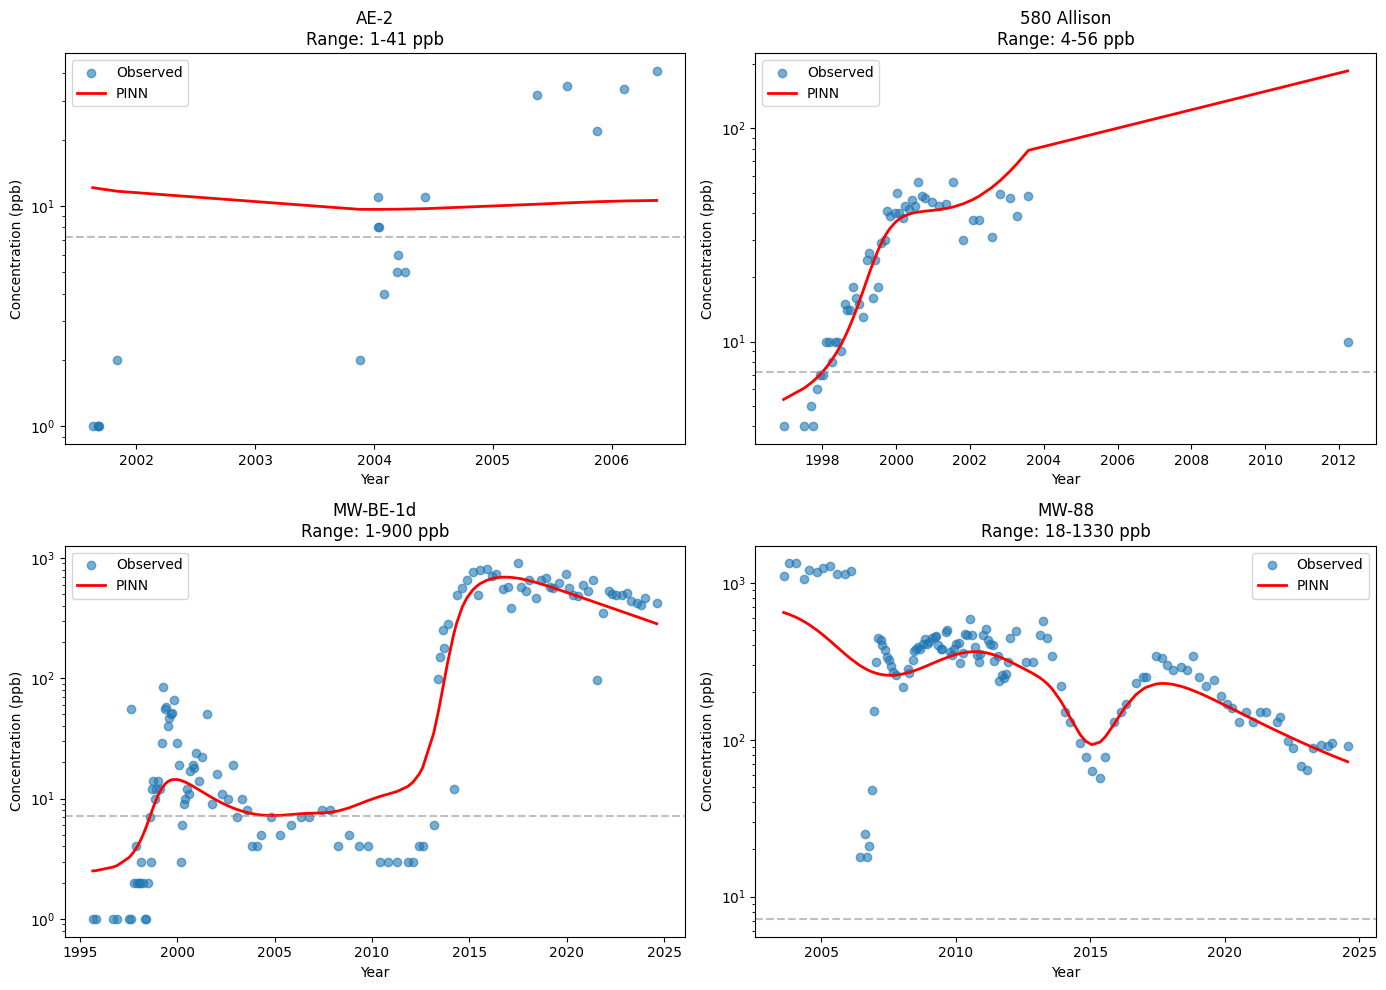

In [12]:
# Depth isn't the issue. The issue is:

# 2 true fringe wells → conservative over-prediction (acceptable)
# 2 high-variance breakthrough wells → model can't capture 900x swings (fundamental limitation)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
outlier_wells = ['AE-2', '580 Allison', 'MW-BE-1d', 'MW-88']

for ax, well in zip(axes.flatten(), outlier_wells):
    subset = full_df[full_df['Bore'] == well].sort_values('t_years')

    ax.scatter(subset['t_years'] + 1986, subset['C_true_ppb'],
               label='Observed', alpha=0.6)
    ax.plot(subset['t_years'] + 1986, subset['C_pred_ppb'],
            'r-', label='PINN', linewidth=2)
    ax.axhline(7.2, color='gray', linestyle='--', alpha=0.5)

    ax.set_yscale('log')
    ax.set_xlabel('Year')
    ax.set_ylabel('Concentration (ppb)')
    ax.set_title(f'{well}\nRange: {subset["C_true_ppb"].min():.0f}-{subset["C_true_ppb"].max():.0f} ppb')
    ax.legend()

plt.tight_layout()
plt.savefig('outlier_wells_temporal.png', dpi=150)
plt.show()

In [13]:
# checking bias at 10,000 ft. prev plot shows bias toward positive residual for 10,000 ft
front_well = full_df[full_df['along_dist_ft'] > 9800][['Bore', 'along_dist_ft']].drop_duplicates()
print(front_well)

       Bore  along_dist_ft
243  MW-104    9910.608942


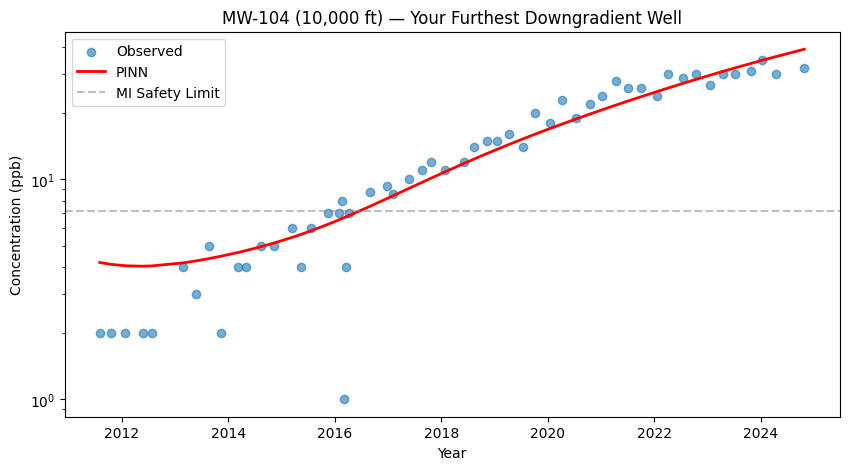

Distance: 9911 ft
Samples: 55
Conc range: 1.0 - 35.0 ppb
Years: 2012 - 2025


In [14]:
well = 'MW-104'
subset = full_df[full_df['Bore'] == well].sort_values('t_years')

plt.figure(figsize=(10, 5))
plt.scatter(subset['t_years'] + 1986, subset['C_true_ppb'], label='Observed', alpha=0.6)
plt.plot(subset['t_years'] + 1986, subset['C_pred_ppb'], 'r-', label='PINN', linewidth=2)
plt.axhline(7.2, color='gray', linestyle='--', alpha=0.5, label='MI Safety Limit')
plt.yscale('log')
plt.xlabel('Year')
plt.ylabel('Concentration (ppb)')
plt.title(f'MW-104 (10,000 ft) — Your Furthest Downgradient Well')
plt.legend()
plt.show()

print(f"Distance: {subset['along_dist_ft'].iloc[0]:.0f} ft")
print(f"Samples: {len(subset)}")
print(f"Conc range: {subset['C_true_ppb'].min():.1f} - {subset['C_true_ppb'].max():.1f} ppb")
print(f"Years: {subset['t_years'].min() + 1986:.0f} - {subset['t_years'].max() + 1986:.0f}")

In [15]:
# From your LOWO results
mw104_lowo = res_df[res_df['Well'] == 'MW-104']
print(mw104_lowo)

     Well      Dist_ft  Screen_ft  Samples  Mean_Obs_ppb  RMSE_ppb    Error_%  \
8  MW-104  9910.608942      147.5       55     14.230909   9.98103  70.136276   

   Log_RMSE  
8  0.344999  
